📁 Найдено изображений: 2535
📌 Выбрано для теста: 5
✅ Сохранено: transform_test_results.png


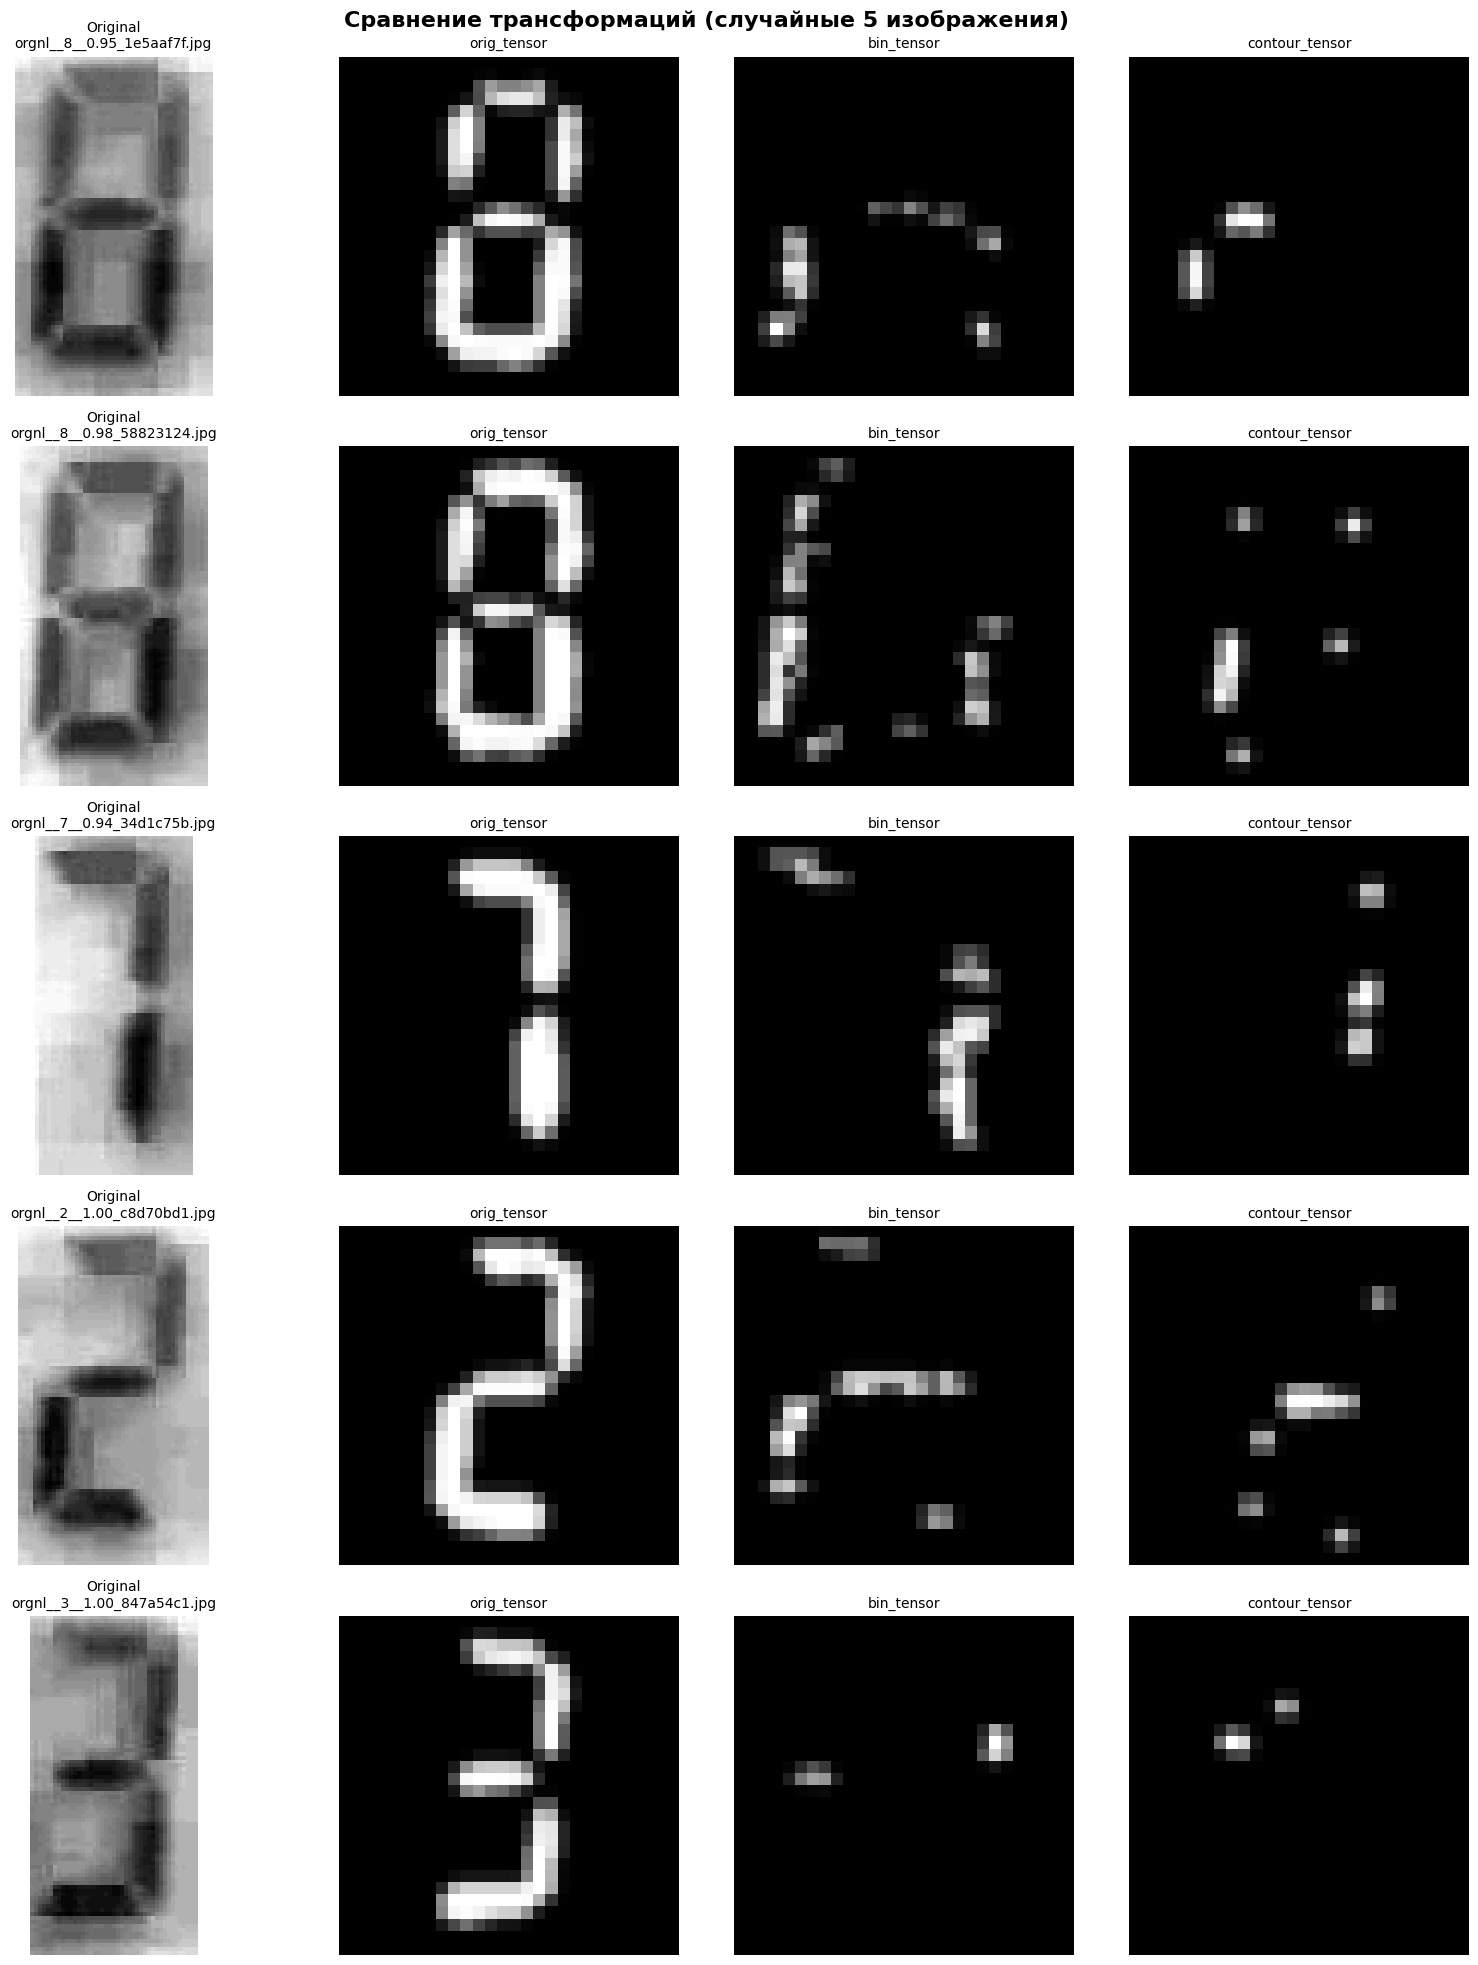

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
from datetime import datetime
from torchvision import transforms

from utils.augmentation import AdaptivePreprocess, BinarizeCV, ExtractLetterWithMargin, Invert, MorphologicalTransform, RemoveSmallObjects, SquarePad, SquarePadAdaptBackground

# ============================================================
# КЛАССЫ ДЛЯ ТРАНСФОРМАЦИЙ
# ============================================================


class ContourAreaFilter:
    """Фильтр по площади контура с объединением близких контуров"""
    
    def __init__(self, min_area=50, dilate_iterations=1, apply_prob=1.0, debug=False):
        """
        Args:
            min_area: минимальная площадь контура (количество пикселей)
            dilate_iterations: количество итераций дилатации для соединения близких контуров
            apply_prob: вероятность применения
            debug: если True - рисует рамки
        """
        self.min_area = min_area
        self.dilate_iterations = dilate_iterations
        self.apply_prob = apply_prob
        self.debug = debug
    
    def __call__(self, image):
        import cv2
        import numpy as np
        import random
        from PIL import Image
        
        if random.random() > self.apply_prob:
            return image
        
        if hasattr(image, 'convert'):
            image_np = np.array(image.convert('L'))
        else:
            image_np = image
        
        if len(image_np.shape) == 3:
            gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
        else:
            gray = image_np
        
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        # ДИЛАТАЦИЯ - соединяет близкие контуры
        if self.dilate_iterations > 0:
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
            thresh_dilated = cv2.dilate(thresh, kernel, iterations=self.dilate_iterations)
        else:
            thresh_dilated = thresh
        
        # Находим контуры на объединенном изображении
        cnts, _ = cv2.findContours(thresh_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        result = gray.copy()
        
        if self.debug:
            debug_img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            # Показываем объединенные контуры синим
            debug_contours = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(debug_contours, cnts, -1, (255, 0, 0), 2)
        
        for c in cnts:
            area = cv2.contourArea(c)  # Попиксельная площадь
            
            if area < self.min_area:
                # Закрашиваем маленькие контуры
                cv2.drawContours(result, [c], -1, 0, -1)
                
                if self.debug:
                    x, y, w, h = cv2.boundingRect(c)
                    cv2.rectangle(debug_img, (x, y), (x+w, y+h), (0, 0, 255), 2)
                    cv2.putText(debug_img, f'REMOVED area:{area:.0f}', (x, y-5), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
            else:
                if self.debug:
                    x, y, w, h = cv2.boundingRect(c)
                    cv2.rectangle(debug_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
                    cv2.putText(debug_img, f'KEPT area:{area:.0f}', (x, y-5), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
        
        if self.debug:
            # Показываем три изображения: оригинал, объединенные контуры, результат
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(gray, cmap='gray')
            axes[0].set_title('Original')
            axes[0].axis('off')
            
            axes[1].imshow(debug_contours)
            axes[1].set_title(f'После дилатации (iter={self.dilate_iterations})\nСиние - объединенные контуры')
            axes[1].axis('off')
            
            axes[2].imshow(debug_img)
            axes[2].set_title('Результат\nКрасные - удалены, Зеленые - оставлены')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            return Image.fromarray(result), Image.fromarray(debug_img)
        
        return Image.fromarray(result)
    

class ContourFilter:
    """Фильтр мелких контуров"""
    
    def __init__(self, min_height=5, min_width=5, min_area=50, max_aspect_ratio=10, apply_prob=1.0):
        self.min_height = min_height
        self.min_width = min_width
        self.min_area = min_area
        self.max_aspect_ratio = max_aspect_ratio
        self.apply_prob = apply_prob
    
    def __call__(self, image):
        import cv2
        import numpy as np
        import random
        
        if random.random() > self.apply_prob:
            return image
        
        if hasattr(image, 'convert'):
            image_np = np.array(image.convert('L'))
        else:
            image_np = image
        
        if len(image_np.shape) == 3:
            gray = cv2.cvtColor(image_np, cv2.COLOR_BGR2GRAY)
        else:
            gray = image_np
        
        # _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        filtered_contours = []
        for c in cnts:
            (x, y, w, h) = cv2.boundingRect(c)
            area = cv2.contourArea(c)
            aspect_ratio = w / h if h > 0 else 0
            
            if h > self.min_height and w > self.min_width and area > self.min_area and aspect_ratio < self.max_aspect_ratio:
                filtered_contours.append(c)
        
        if not filtered_contours:
            return image
        
        mask = np.zeros_like(thresh)
        cv2.drawContours(mask, filtered_contours, -1, 255, -1)
        
        padding = 70
        mask_padded = cv2.copyMakeBorder(
            mask.copy(),
            padding, padding, padding, padding,
            cv2.BORDER_CONSTANT,
            value=0
        )
        
        y_gap_threshold = 5
        kernel_height = y_gap_threshold * 2
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, kernel_height))
        closed = cv2.morphologyEx(mask_padded, cv2.MORPH_CLOSE, kernel)
        
        closed = closed[padding:-padding, padding:-padding]
        
        result = cv2.bitwise_and(gray, gray, mask=closed)
        
        from PIL import Image
        return Image.fromarray(result)


class BinarizeTransform:
    """Бинаризация изображения"""
    
    def __init__(self, method='otsu', apply_prob=1.0):
        """
        method: 'otsu' или 'adaptive'
        """
        self.method = method
        self.apply_prob = apply_prob
    
    def __call__(self, image):
        import cv2
        import numpy as np
        import random
        
        if random.random() > self.apply_prob:
            return image
        
        if hasattr(image, 'convert'):
            image_np = np.array(image.convert('L'))
        else:
            image_np = image
        
        if self.method == 'otsu':
            _, binary = cv2.threshold(image_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        else:  # adaptive
            binary = cv2.adaptiveThreshold(
                image_np, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY, 11, 2
            )
        
        # Инвертируем если цифры белые на черном
        if np.mean(binary) > 127:
            binary = 255 - binary
        
        from PIL import Image
        return Image.fromarray(binary)


# ============================================================
# ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ
# ============================================================

def test_transformations(dataset_path, num_samples=10, save_path=None):
    """
    Тестирует трансформации на случайных изображениях из папки
    
    Args:
        dataset_path: путь к папке с изображениями
        num_samples: количество случайных изображений
        save_path: путь для сохранения результата (опционально)
    """
    
    # Собираем все изображения
    all_images = []
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                all_images.append(os.path.join(root, file))
    
    if not all_images:
        print(f"❌ Нет изображений в {dataset_path}")
        return
    
    # Выбираем случайные
    selected = random.sample(all_images, min(num_samples, len(all_images)))
    print(f"📁 Найдено изображений: {len(all_images)}")
    print(f"📌 Выбрано для теста: {len(selected)}")

    params = {
        'blur_ksize': 7,           # Уменьшено с 7 до 3
        'blur_sigma': 5,           # Уменьшено с 5 до 1
        'adaptive_block_size': 57, # Уменьшено с 57 до 11 (должно быть > 1 и нечетное)
        'adaptive_c': 5,           # Уменьшено с 5 до 3
        'morph_kernel': 2,         # Уменьшено с 2 до 1
        'morph_iter': 1            # Оставлено 1
    }

    # Создаем трансформации
    transform_original = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        # Binarize(),
        # BinarizeTransform(method='adaptive', apply_prob=1.0),
        # OnlyBrighten(max_brightness=2),
        # transforms.Resize(64),
        ExtractLetterWithMargin(margin=20, fill_white=None),
        SquarePadAdaptBackground(min_size=128),
        AdaptivePreprocess(params),
        # ContourFilter(
        #     min_height=2,      # минимальная высота
        #     min_width=2,       # минимальная ширина
        #     min_area=5,       # минимальная площадь
        #     max_aspect_ratio=5, # макс соотношение сторон
        #     apply_prob=1.0     # вероятность применения (1.0 = всегда)
        # ),         
        # SquarePad(fill_white=False),

        # RemoveSmallObjects(min_area=5),

        # ContourAreaFilter(
        #     min_area=500,              # минимальная площадь
        #     dilate_iterations=2,       # сколько раз расширять для соединения
        #     apply_prob=1.0,
        #     debug=False
        # ),
        transforms.CenterCrop((90, 90)),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    
    transform_with_binarize = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        # Binarize(),
        # BinarizeTransform(method='adaptive', apply_prob=1.0),
        # OnlyBrighten(max_brightness=2),
        # transforms.Resize(64),
        AdaptivePreprocess(),
        # BBoxFilter(),
        ContourFilter(
            min_height=2,      # минимальная высота
            min_width=2,       # минимальная ширина
            min_area=5,       # минимальная площадь
            max_aspect_ratio=5, # макс соотношение сторон
            apply_prob=1.0     # вероятность применения (1.0 = всегда)
        ),         
        # SquarePad(fill_white=False),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))


        # BinarizeTransform(method='adaptive', apply_prob=1.0),
        # transforms.Grayscale(num_output_channels=1),
        # SquarePad(fill_white=False),
        # transforms.Resize((28, 28)),
        # transforms.ToTensor(),
        # transforms.Normalize((0.5,), (0.5,))
    ])
    
    transform_with_contour = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        # BinarizeNP(apply_prob=1, threshold=100),
        ExtractLetterWithMargin(margin=20, fill_white=None),
        SquarePadAdaptBackground(min_size=128),
        BinarizeCV(),
        # Invert(),
        # AdaptivePreprocess(apply_prob=0.5),
        # transforms.Resize((128, 128)),
        transforms.RandomRotation(5),
        transforms.RandomAffine(
            degrees=0,  # Измените на нужные значения
            translate=(0.1, 0.1),
            shear=0
        ),    
        transforms.CenterCrop((90, 90)),

        # MorphologicalTransform(
        #     erosion=(1, 1),      # эрозия 0-2 итерации
        #     dilation=(1, 1),     # дилатация 0-2 итерации
        #     kernel_size=(5, 5),  # ядро 1-3
        #     prob=1            # 50% вероятность
        # ),  

        transforms.Resize((28, 28)),
        # OnlyBrighten(max_brightness=2.5),

        # Binarize(),
        # BinarizeTransform(method='adaptive', apply_prob=1.0),
        # OnlyBrighten(max_brightness=2),
        # transforms.Resize(64),
        # AdaptivePreprocess(),
        # BBoxFilter(),
        # ContourFilter(
        #     min_height=2,      # минимальная высота
        #     min_width=2,       # минимальная ширина
        #     min_area=5,       # минимальная площадь
        #     max_aspect_ratio=5, # макс соотношение сторон
        #     apply_prob=1.0     # вероятность применения (1.0 = всегда)
        # ),         
        # SquarePad(fill_white=False),
        transforms.Resize((28, 28)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))

        # BinarizeTransform(method='adaptive', apply_prob=1.0),
        # ContourFilter(min_height=5, min_width=5, min_area=50, max_aspect_ratio=10, apply_prob=1.0),
        # transforms.Grayscale(num_output_channels=1),
        # SquarePad(fill_white=False),
        # transforms.Resize((28, 28)),
        # transforms.ToTensor(),
        # transforms.Normalize((0.5,), (0.5,))
    ])
    
    # Визуализация
    fig, axes = plt.subplots(len(selected), 4, figsize=(16, len(selected) * 4))
    
    if len(selected) == 1:
        axes = axes.reshape(1, -1)
    
    for idx, img_path in enumerate(selected):
        # Загружаем оригинал
        img = Image.open(img_path)
        img_gray = img.convert('L')
        img_np = np.array(img_gray)
        
        # Применяем трансформации
        orig_tensor = transform_original(img)
        bin_tensor = transform_with_binarize(img)
        contour_tensor = transform_with_contour(img)
        
        # Денормализация для отображения
        def denorm(tensor):
            """Денормализация тензора для отображения"""
            # Берем первый канал если их несколько
            if len(tensor.shape) == 3:
                tensor = tensor[0:1]  # (1, H, W)
            # Денормализация
            img = tensor.clone()
            if img.min() < 0:
                img = (img + 1) / 2
            img = img.clamp(0, 1)
            # Убираем размерность канала
            return img.squeeze().numpy()
        
        # Отображение
        axes[idx, 0].imshow(img_np, cmap='gray')
        axes[idx, 0].set_title(f'Original\n{os.path.basename(img_path)}', fontsize=10)
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(denorm(orig_tensor), cmap='gray')
        axes[idx, 1].set_title('orig_tensor', fontsize=10)
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(denorm(bin_tensor), cmap='gray')
        axes[idx, 2].set_title('bin_tensor', fontsize=10)
        axes[idx, 2].axis('off')
        
        axes[idx, 3].imshow(denorm(contour_tensor), cmap='gray')
        axes[idx, 3].set_title('contour_tensor', fontsize=10)
        axes[idx, 3].axis('off')
    
    plt.suptitle(f'Сравнение трансформаций (случайные {len(selected)} изображения)', 
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # Сохраняем если указан путь
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"✅ Сохранено: {save_path}")
    
    plt.show()
    
    return selected


# ============================================================
# ФУНКЦИЯ ДЛЯ ТЕСТИРОВАНИЯ ОДНОГО ИЗОБРАЖЕНИЯ (ПОДРОБНО)
# ============================================================

def test_single_image_detailed(image_path):
    """
    Подробное тестирование одного изображения со всеми этапами
    """
    import cv2
    
    img = Image.open(image_path)
    img_np = np.array(img.convert('L'))
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # 1. Оригинал
    axes[0, 0].imshow(img_np, cmap='gray')
    axes[0, 0].set_title('1. Original', fontsize=12)
    axes[0, 0].axis('off')
    
    # 2. Бинаризация
    binary = BinarizeTransform(method='otsu', apply_prob=1.0)(img)
    binary_np = np.array(binary)
    axes[0, 1].imshow(binary_np, cmap='gray')
    axes[0, 1].set_title('2. Binarized', fontsize=12)
    axes[0, 1].axis('off')
    
    # 3. Контуры (визуализация)
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_BGR2GRAY) if len(np.array(img).shape) == 3 else np.array(img)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    img_contours = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_contours, cnts, -1, (0, 255, 0), 2)
    axes[0, 2].imshow(img_contours)
    axes[0, 2].set_title(f'3. Contours ({len(cnts)})', fontsize=12)
    axes[0, 2].axis('off')
    
    # 4. Фильтрованные контуры
    filtered = ContourFilter(apply_prob=1.0)(img)
    filtered_np = np.array(filtered)
    axes[0, 3].imshow(filtered_np, cmap='gray')
    axes[0, 3].set_title('4. After Contour Filter', fontsize=12)
    axes[0, 3].axis('off')
    
    # 5. Resize (28x28)
    transform_resize = transforms.Compose([
        SquarePad(fill_white=False),
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])
    resized = transform_resize(img)
    axes[1, 0].imshow(resized.squeeze().numpy(), cmap='gray')
    axes[1, 0].set_title('5. Resized (28x28)', fontsize=12)
    axes[1, 0].axis('off')
    
    # 6. Binarize + Resize
    transform_bin = transforms.Compose([
        BinarizeTransform(apply_prob=1.0),
        SquarePad(fill_white=False),
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])
    bin_resized = transform_bin(img)
    axes[1, 1].imshow(bin_resized.squeeze().numpy(), cmap='gray')
    axes[1, 1].set_title('6. Binarize + Resize', fontsize=12)
    axes[1, 1].axis('off')
    
    # 7. Full pipeline
    transform_full = transforms.Compose([
        BinarizeTransform(apply_prob=1.0),
        ContourFilter(apply_prob=1.0),
        SquarePad(fill_white=False),
        transforms.Resize((28, 28)),
        transforms.ToTensor()
    ])
    full = transform_full(img)
    axes[1, 2].imshow(full.squeeze().numpy(), cmap='gray')
    axes[1, 2].set_title('7. Full Pipeline', fontsize=12)
    axes[1, 2].axis('off')
    
    # 8. Гистограмма
    axes[1, 3].hist(img_np.flatten(), bins=50, alpha=0.7)
    axes[1, 3].set_title('8. Histogram', fontsize=12)
    axes[1, 3].axvline(np.mean(img_np), color='red', linestyle='--', label=f'Mean: {np.mean(img_np):.1f}')
    axes[1, 3].legend()
    
    plt.suptitle(f'Подробный анализ: {os.path.basename(image_path)}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================================
# ЗАПУСК
# ============================================================

if __name__ == "__main__":
    # Путь к датасету
    # dataset_path = "/media/vadim/1TB_SSD/my_github/meter-watch/dataset_old"
    dataset_path = "/media/vadim/1TB_SSD/my_github/meter-watch/dataset_val_clean"
    
    # Тест на 10 случайных изображениях
    test_transformations(
        dataset_path=dataset_path,
        num_samples=5,
        save_path="transform_test_results.png"
    )
    
    # Детальный тест одного изображения (раскомментировать)
    # test_single_image_detailed("/path/to/specific/image.png")